In [1]:
import numpy as np
import pandas as pd
original_matrix = pd.read_csv("prs_adjauc_matrix_260217_rootcode_qc.csv")
original_matrix = original_matrix.set_index("trait")
rank_matrix = pd.read_csv("prs_adjauc_matrix_260217_rootcode_rankmatrix.csv")
rank_matrix = rank_matrix.set_index("trait")
target_rank_matrix = pd.read_csv("prs_adjauc_matrix_260217_rootcode_selfrankmatrix.csv")
target_rank_matrix = target_rank_matrix.set_index("trait")
metainfo = pd.read_csv("../../disease_preprocess/pgs_metadata_260217.csv", encoding='latin-1')
metainfo = metainfo.drop_duplicates(subset="PGS_ID", keep="first").set_index("PGS_ID")

## Across All Available Candidate PGS

### Histogram of the Best Performing PGS 

C62 0.9225928246273298
O14 0.9466824434304602


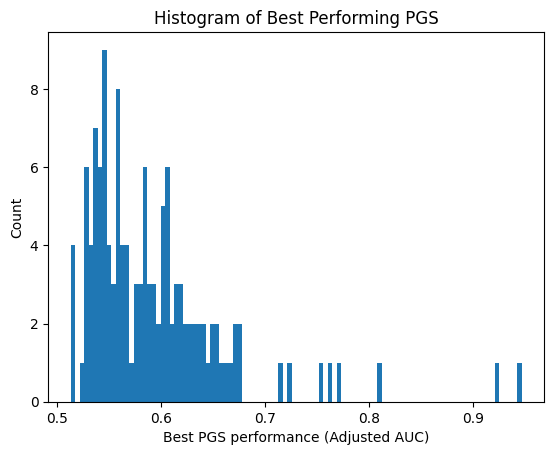

In [3]:
import matplotlib.pyplot as plt
matrix = original_matrix.copy()
max_list = []
for trait in matrix.index:
    max_list.append(max(matrix.loc[trait]))
    if max(matrix.loc[trait]) > 0.9:
        print(trait, max(matrix.loc[trait]))
plt.figure()
plt.hist(max_list, bins=100)
plt.xlabel("Best PGS performance (Adjusted AUC)")
plt.ylabel("Count")
plt.title("Histogram of Best Performing PGS")
plt.show()

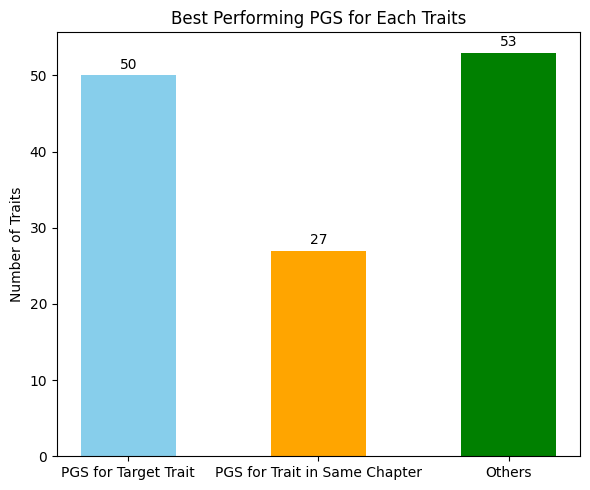

In [4]:
self_pgs_count = 0
same_chap_count = 0
others = 0
for trait in rank_matrix.index:

    best_pgs = rank_matrix.loc[trait].iloc[0]
    chapter = str(trait[0])

    if trait in best_pgs.split("__")[0].split("+"):
        self_pgs_count += 1
        continue
    
    elif any(chapter in item for item in best_pgs.split("__")[0].split("+")):
        same_chap_count += 1
    
    else:
        others += 1

counts = [self_pgs_count, same_chap_count, others]
labels = ["PGS for Target Trait", "PGS for Trait in Same Chapter", "Others"]
x = [0, 3, 6] 

plt.figure(figsize=(6,5))
plt.bar(x, counts, color=["skyblue", "orange", "green"], width=1.5)
plt.xticks(x, labels)
plt.ylabel("Number of Traits")
plt.title("Best Performing PGS for Each Traits")
for i, count in enumerate(counts):
    plt.text(x[i], count + 0.5, str(count), ha='center', va='bottom')

plt.tight_layout()
plt.show()

D64
F43
I49
L28
M47
Q74
R94


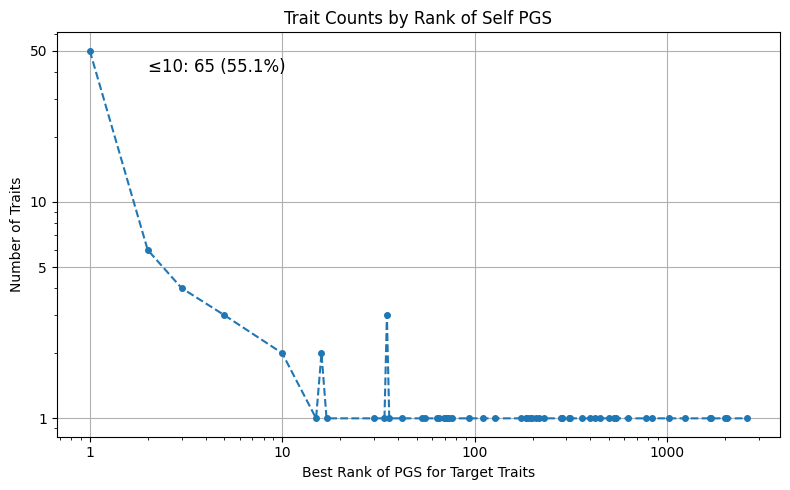

In [5]:
from collections import Counter

best_self_pgs_rank = []
for trait in rank_matrix.index:

    for idx, m in enumerate(rank_matrix.loc[trait]):
        
        if trait in m.split("__")[0].split("+"):
            best_self_pgs_rank.append(idx + 1)
            if idx > 1000:
                print(trait)
            break


rank_counts = Counter(best_self_pgs_rank)
ranks = sorted(rank_counts.keys())
counts = [rank_counts[r] for r in ranks]

total_traits = len(best_self_pgs_rank)
num_top10 = sum(
    count for r, count in rank_counts.items() if r <= 10
)
ratio = num_top10 / total_traits

plt.figure(figsize=(8,5))
plt.plot(ranks, counts, '--', marker='o', markersize=4)

plt.text(
    2, max(counts)*0.8,
    f"≤10: {num_top10} ({ratio:.1%})",
    fontsize=12
)

plt.xlabel("Best Rank of PGS for Target Traits")
plt.ylabel("Number of Traits")
plt.title("Trait Counts by Rank of Self PGS")
plt.xscale('log')
plt.yscale('log')
plt.xticks([1, 10, 100, 1000], ["1", "10", "100", "1000"])
plt.yticks([1, 5, 10, 50], ["1", "5", "10", "50"])
plt.grid(0.6)
plt.tight_layout()
plt.show()

### Histogram of the Worse Performing PGS 

C62 0.1034040532334873
O14 0.0531737673133091


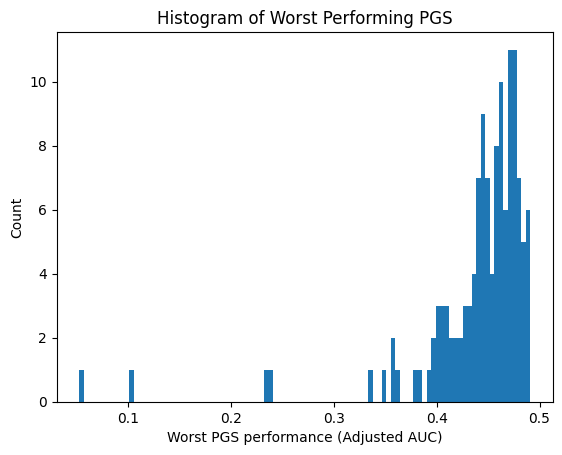

In [5]:
matrix = original_matrix.copy()
max_list = []
for trait in matrix.index:
    max_list.append(min(matrix.loc[trait]))
    if min(matrix.loc[trait]) < 0.2:
        print(trait, min(matrix.loc[trait]))
plt.figure()
plt.hist(max_list, bins=100)
plt.xlabel("Worst PGS performance (Adjusted AUC)")
plt.ylabel("Count")
plt.title("Histogram of Worst Performing PGS")
plt.show()

### Histogram of the PRS Performing Range

C62 0.8191887713938425
O14 0.893508676117151


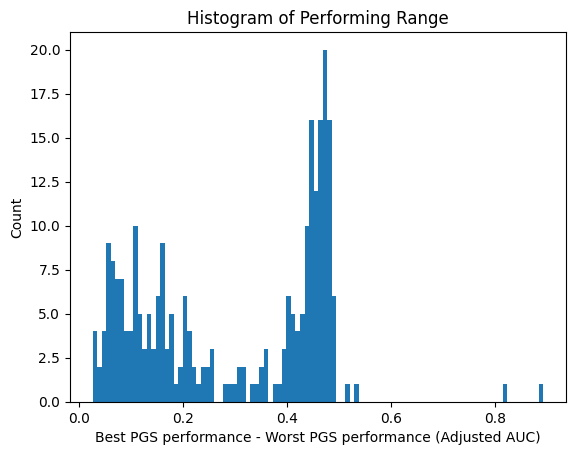

In [6]:
matrix = original_matrix.copy()
for trait in matrix.index:
    temp = max(matrix.loc[trait]) - min(matrix.loc[trait])
    max_list.append(temp)
    if temp > 0.8:
        print(trait, temp)
plt.hist(max_list, bins=100)
plt.xlabel("Best PGS performance - Worst PGS performance (Adjusted AUC)")
plt.ylabel("Count")
plt.title("Histogram of Performing Range")
plt.show()

In [7]:
diff_dict = {}

for trait in matrix.index:
    values = matrix.loc[trait].values.astype(float)
    diff = np.nanmax(values) - np.nanmin(values)
    diff_dict[trait] = diff

large_diff_traits = [t for t, d in diff_dict.items() if d > 0.4]
print("Traits with performance range bigget than 0.4: ", large_diff_traits)

Traits with performance range bigget than 0.4:  ['C53', 'C62', 'O14', 'O36']


### Histogram of Range Between Median and the Best

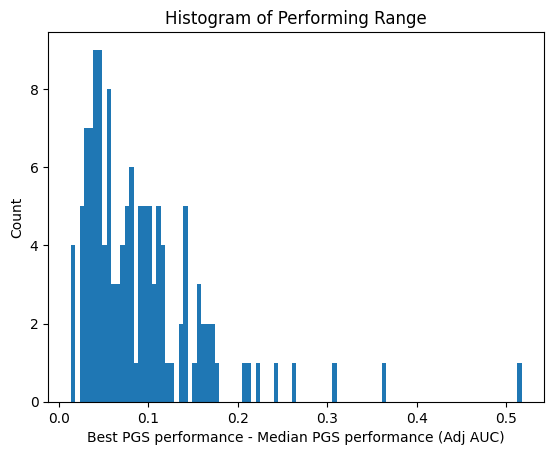

In [8]:
matrix = original_matrix.copy()
max_list = [max(matrix.loc[trait]) - np.median(matrix.loc[trait]) for trait in matrix.index]
plt.figure()
plt.hist(max_list, bins=100)
plt.xlabel("Best PGS performance - Median PGS performance (Adj AUC)")
plt.ylabel("Count")
plt.title("Histogram of Performing Range")
plt.show() 

In [9]:
diff_dict = {}

for trait in matrix.index:
    values = matrix.loc[trait].values.astype(float)
    diff = np.nanmax(values) - np.median(values)
    diff_dict[trait] = diff

large_diff_traits = [t for t, d in diff_dict.items() if d > 0.3]
print("Traits with performance range bigget than 0.3: ", large_diff_traits)

Traits with performance range bigget than 0.3:  ['C62', 'C73', 'O14']


## Across Target PGS Only

### Histogram of the Best PGS

C62 0.921215218378967


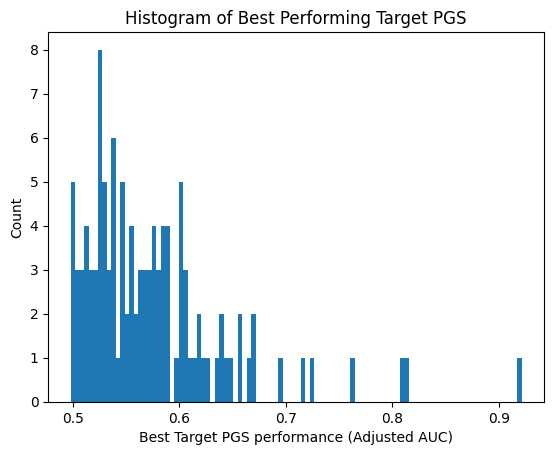

In [2]:
import matplotlib.pyplot as plt
matrix = original_matrix.copy()
max_list = []
for trait in target_rank_matrix.index:
    self_cols = target_rank_matrix.loc[trait].dropna().tolist()
    if not self_cols:
        continue
    best_auc = max(matrix.loc[trait, self_cols])
    max_list.append(best_auc)
    if best_auc > 0.9:
        print(trait, best_auc)
plt.figure()
plt.hist(max_list, bins=100)
plt.xlabel("Best Target PGS performance (Adjusted AUC)")
plt.ylabel("Count")
plt.title("Histogram of Best Performing Target PGS")
plt.show()

### Histogram of the Worst PGS

C53 0.3376965231163036


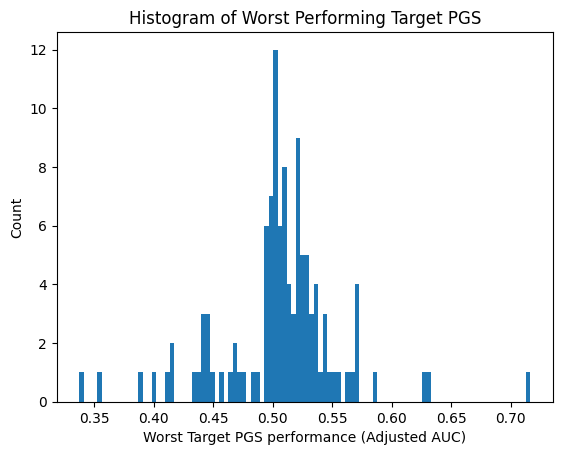

In [3]:
matrix = original_matrix.copy()
max_list = []
for trait in target_rank_matrix.index:
    self_cols = target_rank_matrix.loc[trait].dropna().tolist()
    if not self_cols:
        continue
    worst_auc = min(matrix.loc[trait, self_cols])
    max_list.append(worst_auc)
    if worst_auc < 0.35:
        print(trait, worst_auc)
plt.figure()
plt.hist(max_list, bins=100)
plt.xlabel("Worst Target PGS performance (Adjusted AUC)")
plt.ylabel("Count")
plt.title("Histogram of Worst Performing Target PGS")
plt.show()

### Histogram of the Range

C62 0.507199964800406


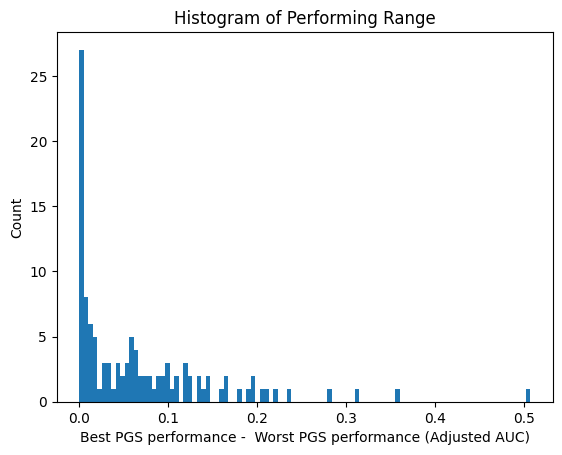

In [4]:
matrix = original_matrix.copy()
max_list = []
for trait in target_rank_matrix.index:
    self_cols = target_rank_matrix.loc[trait].dropna().tolist()
    if not self_cols:
        continue
    auc_range = max(matrix.loc[trait, self_cols]) - min(matrix.loc[trait, self_cols])
    max_list.append(auc_range)
    if auc_range > 0.5:
        print(trait, auc_range)
plt.figure()
plt.hist(max_list, bins=100)
plt.xlabel("Best PGS performance -  Worst PGS performance (Adjusted AUC)")
plt.ylabel("Count")
plt.title("Histogram of Performing Range")
plt.show()

### Correlation: Number of Variants - Performance

In [3]:
def add_significance(ax, x1, x2, y, p):
    h = y * 0.05
    ax.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=1.5)
    
    if p < 0.001:
        text = "***"
    elif p < 0.01:
        text = "**"
    elif p < 0.05:
        text = "*"
    else:
        text = "ns"
    
    ax.text((x1+x2)/2, y+h, text, ha='center', va='bottom')

In [4]:
from scipy.stats import gaussian_kde

def half_violin(ax, data, pos, color, width=0.3, side='right', alpha=0.75, log_scale=False):
    data = np.array(data)
    
    if log_scale:
        data_fit = np.log10(data[data > 0])  # KDE 在 log 空间
    else:
        data_fit = data
    
    kde = gaussian_kde(data_fit, bw_method=0.3)
    y_fit = np.linspace(data_fit.min(), data_fit.max(), 300)
    x = kde(y_fit)
    x = x / x.max() * width
    
    y_plot = 10 ** y_fit if log_scale else y_fit  # 转回原始尺度
    
    if side == 'right':
        ax.fill_betweenx(y_plot, pos, pos + x, color=color, alpha=alpha, linewidth=0)
        ax.plot(pos + x, y_plot, color=color, linewidth=0.8)
    else:
        ax.fill_betweenx(y_plot, pos - x, pos, color=color, alpha=alpha, linewidth=0)
        ax.plot(pos - x, y_plot, color=color, linewidth=0.8)

In [4]:
num_variant_best = []
num_variant_median = []
num_variant_worst = []

for trait in rank_matrix.index:

    pgs_list = []
    num_list = []

    for m in rank_matrix.loc[trait]:

        if trait not in m.split("__")[0].split("+"):
            continue

        temp_id = m.split("__")[1]

        pgs_list.append(temp_id)

        num_var = metainfo.loc[temp_id]["num_variant"]
        num_list.append(num_var)

    if len(num_list) < 3:
        continue
    num_array = np.array(num_list)
    best = num_array[0]
    worst = num_array[-1]
    median = num_array[len(num_array) // 2]

    num_variant_best.append(best)
    num_variant_median.append(median)
    num_variant_worst.append(worst)

Global p: 0.005239701125242129


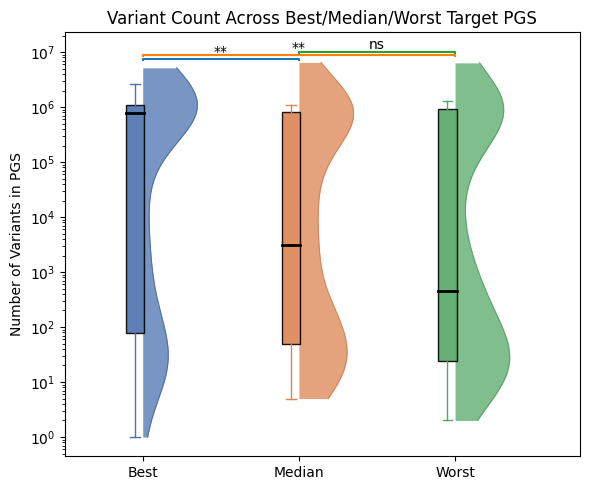

In [5]:
import matplotlib.pyplot as plt
from scipy.stats import kruskal, mannwhitneyu

# hypothesis testing
# overall test
stat, p_global = kruskal(
    num_variant_best,
    num_variant_median,
    num_variant_worst
)

print("Global p:", p_global)

# pairwise
p1 = mannwhitneyu(num_variant_best, num_variant_median).pvalue
p2 = mannwhitneyu(num_variant_best, num_variant_worst).pvalue
p3 = mannwhitneyu(num_variant_median, num_variant_worst).pvalue

colors = ['#4C72B0', '#DD8452', '#55A868']
labels = ["Best", "Median", "Worst"]
data = [num_variant_best, num_variant_median, num_variant_worst]
positions = [1, 2, 3]

fig, ax = plt.subplots(figsize=(6, 5))

for pos, d, color, label in zip(positions, data, colors, labels):
    # half violin plot
    half_violin(ax, d, pos, color, width=0.35, log_scale=True) 
    
    # half box plot
    bp = ax.boxplot(d, positions=[pos - 0.05], widths=0.12,
                    showfliers=False, patch_artist=True,
                    medianprops=dict(color='black', linewidth=2),
                    boxprops=dict(facecolor=color, alpha=0.9),
                    whiskerprops=dict(color=color),
                    capprops=dict(color=color))
ax.set_yscale("log")
ax.set_xticks(positions)
ax.set_xticklabels(labels)
ax.set_xlim(0.5, 3.8)
ax.set_ylabel("Number of Variants in PGS")
ax.set_title("Variant Count Across Best/Median/Worst Target PGS")

y_max = max([max(d) for d in data])
add_significance(ax, 1, 2, y_max * 1.1, p1)
add_significance(ax, 1, 3, y_max * 1.3, p2)
add_significance(ax, 2, 3, y_max * 1.5, p3)

plt.tight_layout()
plt.show()

### Correlation: Date Release - Performance

In [6]:
matrix = original_matrix.copy()
today = pd.Timestamp.today()

days_best = []
days_median = []
days_worst = []

for trait in rank_matrix.index:

    days_list = []

    for m in rank_matrix.loc[trait]:

        if trait not in m.split("__")[0].split("+"):
            continue

        temp_id = m.split("__")[1]

        release_date = pd.to_datetime(metainfo.loc[temp_id]["date_release"])
        days_diff = (today - release_date).days

        days_list.append(days_diff)

    if len(days_list) < 3:
        continue

    days_array = np.array(days_list)

    days_best.append(days_array[0])
    days_median.append(days_array[len(days_array)//2])
    days_worst.append(days_array[-1])

Global p: 0.0024102980364232966


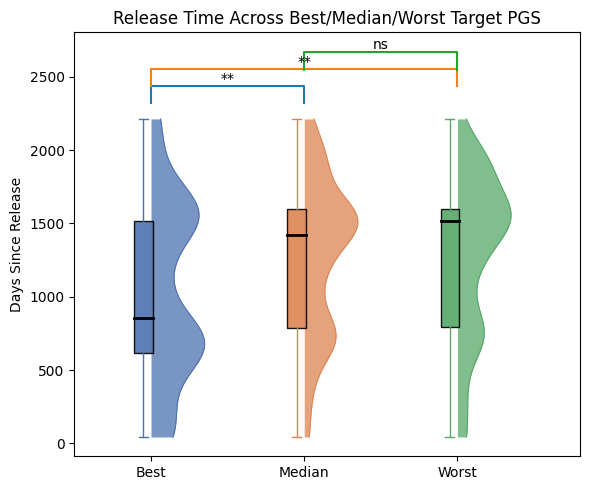

In [7]:
import matplotlib.pyplot as plt

num_variant_best = [x for x in days_best if pd.notna(x)]
num_variant_median = [x for x in days_median if pd.notna(x)]
num_variant_worst = [x for x in days_worst if pd.notna(x)]

# hypothesis testing
# overall test
stat, p_global = kruskal(
    num_variant_best,
    num_variant_median,
    num_variant_worst
)

print("Global p:", p_global)

# pairwise
p1 = mannwhitneyu(num_variant_best, num_variant_median).pvalue
p2 = mannwhitneyu(num_variant_best, num_variant_worst).pvalue
p3 = mannwhitneyu(num_variant_median, num_variant_worst).pvalue

colors = ['#4C72B0', '#DD8452', '#55A868']
labels = ["Best", "Median", "Worst"]
data = [num_variant_best, num_variant_median, num_variant_worst]  # 这里存的是 days
positions = [1, 2, 3]

fig, ax = plt.subplots(figsize=(6, 5))

for pos, d, color in zip(positions, data, colors):
    half_violin(ax, d, pos, color, width=0.35, log_scale=False)
    
    ax.boxplot(d, positions=[pos - 0.05], widths=0.12,
               showfliers=False, patch_artist=True,
               medianprops=dict(color='black', linewidth=2),
               boxprops=dict(facecolor=color, alpha=0.9),
               whiskerprops=dict(color=color),
               capprops=dict(color=color))

ax.set_xticks(positions)
ax.set_xticklabels(labels)
ax.set_xlim(0.5, 3.8)
ax.set_ylabel("Days Since Release")
ax.set_title("Release Time Across Best/Median/Worst Target PGS")

y_max = max([max(d) for d in data])
add_significance(ax, 1, 2, y_max * 1.05, p1)
add_significance(ax, 1, 3, y_max * 1.10, p2)
add_significance(ax, 2, 3, y_max * 1.15, p3)

plt.tight_layout()
plt.show()

### Correlation: Reported Performance - Performance

#### Odds Ratio

In [5]:
from scipy.stats import norm

def beta_to_auc(beta):
    return norm.cdf(beta / np.sqrt(2))

def or_to_auc(OR):
    beta = np.log(OR)
    return norm.cdf(beta / np.sqrt(2))

def partial_r_to_auc(r):
    d = 2*r / np.sqrt(1 - r**2)
    return norm.cdf(d / np.sqrt(2))

def perpare_report_performance(eval_estimate: list, eval_ancestry: list, eval_metrics: list) -> float:
    result = []
    for idx, estimate in enumerate(eval_estimate):
        if not eval_ancestry[idx] == 'European':
            continue
        metric = eval_metrics[idx]
        if not metric == "Odds Ratio":
            continue
        result.append(estimate)
    if len(result) > 0:
        return float(np.mean(result))
    else:
        return np.nan

In [13]:
import ast
matrix = original_matrix.copy()
today = pd.Timestamp.today()

days_best = []
days_median = []
days_worst = []

for trait in rank_matrix.index:

    days_list = []

    for m in rank_matrix.loc[trait]:

        if trait not in m.split("__")[0].split("+"):
            continue

        temp_id = m.split("__")[1]

        eval_estimate = ast.literal_eval(metainfo.loc[temp_id]["eval_estimate"])
        eval_ancestry = ast.literal_eval(metainfo.loc[temp_id]["eval_ancestry"])
        eval_metrics = ast.literal_eval(metainfo.loc[temp_id]["eval_metrics"])
        num_var = perpare_report_performance(eval_estimate, eval_ancestry, eval_metrics)

        days_list.append(num_var)

    if len(days_list) < 3:
        continue

    days_array = np.array(days_list)

    days_best.append(days_array[0])
    days_median.append(days_array[len(days_array)//2])
    days_worst.append(days_array[-1])

In [14]:
print(num_variant_median)

[1.12, 1.57, 1.342, 1.69, 1.207, 1.8239999999999998, 2.055, 1.58, 1.292, 1.5150000000000001, 1.308, 1.5, 1.35970338057817, 1.30179, 1.18671903610809, 1.47, 1.76, 1.429443, 1.28137008181119, 1.1581499383831, 1.37056157164374, 1.13492349113959, 1.28, 1.2225, 6.279999999999999, 1.5005094575, 1.5975, 1.2266666666666666, 1.32326102443575, 1.1847546866666667, 1.4275, 1.22730929818809, 1.537]


Global p: 0.014433893850023949


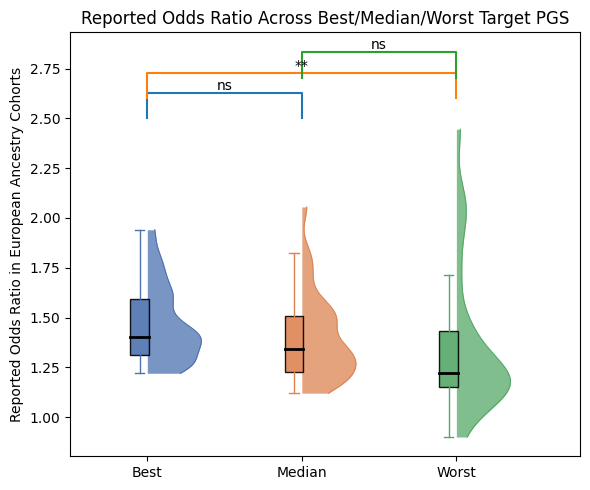

In [17]:
import matplotlib.pyplot as plt
from scipy.stats import kruskal, mannwhitneyu

num_variant_best = [x for x in days_best if pd.notna(x)]
num_variant_median = [x for x in days_median if pd.notna(x)]
num_variant_worst = [x for x in days_worst if pd.notna(x)]

# hypothesis testing
# overall test
stat, p_global = kruskal(
    num_variant_best,
    num_variant_median,
    num_variant_worst
)

print("Global p:", p_global)

# pairwise
p1 = mannwhitneyu(num_variant_best, num_variant_median).pvalue
p2 = mannwhitneyu(num_variant_best, num_variant_worst).pvalue
p3 = mannwhitneyu(num_variant_median, num_variant_worst).pvalue

colors = ['#4C72B0', '#DD8452', '#55A868']
labels = ["Best", "Median", "Worst"]
data = [num_variant_best, num_variant_median, num_variant_worst]
positions = [1, 2, 3]

fig, ax = plt.subplots(figsize=(6, 5))

for pos, d, color in zip(positions, data, colors):
    half_violin(ax, d, pos, color, width=0.35, log_scale=False)
    ax.boxplot(d, positions=[pos - 0.05], widths=0.12,
               showfliers=False, patch_artist=True,
               medianprops=dict(color='black', linewidth=2),
               boxprops=dict(facecolor=color, alpha=0.9),
               whiskerprops=dict(color=color),
               capprops=dict(color=color))

ax.set_xticks(positions)
ax.set_xticklabels(labels)
ax.set_xlim(0.5, 3.8)
ax.set_ylabel("Reported Odds Ratio in European Ancestry Cohorts")
ax.set_title("Reported Odds Ratio Across Best/Median/Worst Target PGS")

add_significance(ax, 1, 2, 2.5, p1)
add_significance(ax, 1, 3, 2.6, p2)
add_significance(ax, 2, 3, 2.7, p3)

plt.tight_layout()
plt.show()

#### Adjusted AUC

In [29]:
from scipy.stats import norm

def beta_to_auc(beta):
    return norm.cdf(beta / np.sqrt(2))

def or_to_auc(OR):
    beta = np.log(OR)
    return norm.cdf(beta / np.sqrt(2))

def partial_r_to_auc(r):
    d = 2*r / np.sqrt(1 - r**2)
    return norm.cdf(d / np.sqrt(2))

def perpare_report_performance(eval_estimate: list, eval_ancestry: list, eval_metrics: list) -> float:
    result = []
    for idx, estimate in enumerate(eval_estimate):
        if not eval_ancestry[idx] == 'European':
            continue
        metric = eval_metrics[idx]
        if not metric == "Area Under the Receiver-Operating Characteristic Curve":
            continue
        result.append(estimate)
    if len(result) > 0:
        return float(np.mean(result))
    else:
        return np.nan
    
import ast
matrix = original_matrix.copy()
today = pd.Timestamp.today()

days_best = []
days_median = []
days_worst = []

for trait in rank_matrix.index:

    days_list = []

    for m in rank_matrix.loc[trait]:

        if trait not in m.split("__")[0].split("+"):
            continue

        temp_id = m.split("__")[1]

        eval_estimate = ast.literal_eval(metainfo.loc[temp_id]["eval_estimate"])
        eval_ancestry = ast.literal_eval(metainfo.loc[temp_id]["eval_ancestry"])
        eval_metrics = ast.literal_eval(metainfo.loc[temp_id]["eval_metrics"])
        num_var = perpare_report_performance(eval_estimate, eval_ancestry, eval_metrics)

        days_list.append(num_var)

    if len(days_list) < 3:
        continue

    days_array = np.array(days_list)

    days_best.append(days_array[0])
    days_median.append(days_array[len(days_array)//2])
    days_worst.append(days_array[-1])

In [30]:
print(len(num_variant_best), len(num_variant_median), len(num_variant_worst))

8 6 9


Global p: 0.6926295133872248


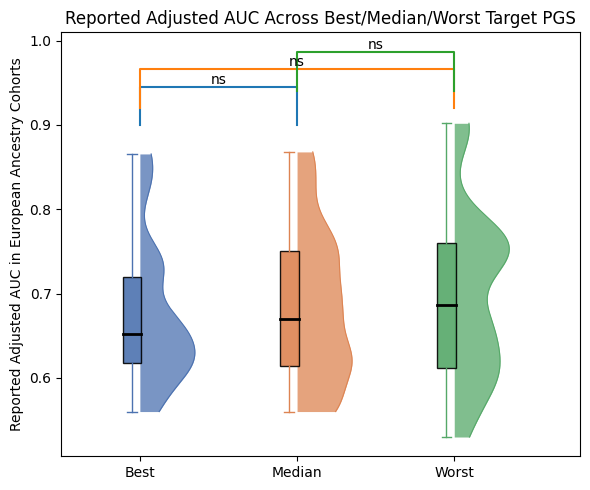

In [31]:
import matplotlib.pyplot as plt
from scipy.stats import kruskal, mannwhitneyu

num_variant_best = [x for x in days_best if pd.notna(x)]
num_variant_median = [x for x in days_median if pd.notna(x)]
num_variant_worst = [x for x in days_worst if pd.notna(x)]

# hypothesis testing
# overall test
stat, p_global = kruskal(
    num_variant_best,
    num_variant_median,
    num_variant_worst
)

print("Global p:", p_global)

# pairwise
p1 = mannwhitneyu(num_variant_best, num_variant_median).pvalue
p2 = mannwhitneyu(num_variant_best, num_variant_worst).pvalue
p3 = mannwhitneyu(num_variant_median, num_variant_worst).pvalue

colors = ['#4C72B0', '#DD8452', '#55A868']
labels = ["Best", "Median", "Worst"]
data = [num_variant_best, num_variant_median, num_variant_worst]
positions = [1, 2, 3]

fig, ax = plt.subplots(figsize=(6, 5))

for pos, d, color in zip(positions, data, colors):
    half_violin(ax, d, pos, color, width=0.35, log_scale=False)
    ax.boxplot(d, positions=[pos - 0.05], widths=0.12,
               showfliers=False, patch_artist=True,
               medianprops=dict(color='black', linewidth=2),
               boxprops=dict(facecolor=color, alpha=0.9),
               whiskerprops=dict(color=color),
               capprops=dict(color=color))

ax.set_xticks(positions)
ax.set_xticklabels(labels)
ax.set_xlim(0.5, 3.8)
ax.set_ylabel("Reported Adjusted AUC in European Ancestry Cohorts")
ax.set_title("Reported Adjusted AUC Across Best/Median/Worst Target PGS")

add_significance(ax, 1, 2, 0.90, p1)
add_significance(ax, 1, 3, 0.92, p2)
add_significance(ax, 2, 3, 0.94, p3)

plt.tight_layout()
plt.show()

#### Hazard Ratio

In [23]:
from scipy.stats import norm

def beta_to_auc(beta):
    return norm.cdf(beta / np.sqrt(2))

def or_to_auc(OR):
    beta = np.log(OR)
    return norm.cdf(beta / np.sqrt(2))

def partial_r_to_auc(r):
    d = 2*r / np.sqrt(1 - r**2)
    return norm.cdf(d / np.sqrt(2))

def perpare_report_performance(eval_estimate: list, eval_ancestry: list, eval_metrics: list) -> float:
    result = []
    for idx, estimate in enumerate(eval_estimate):
        if not eval_ancestry[idx] == 'European':
            continue
        metric = eval_metrics[idx]
        if not metric == "Hazard Ratio":
            continue
        result.append(estimate)
    if len(result) > 0:
        return float(np.mean(result))
    else:
        return np.nan
    
import ast
matrix = original_matrix.copy()
today = pd.Timestamp.today()

days_best = []
days_median = []
days_worst = []

for trait in rank_matrix.index:

    days_list = []

    for m in rank_matrix.loc[trait]:

        if trait not in m.split("__")[0].split("+"):
            continue

        temp_id = m.split("__")[1]

        eval_estimate = ast.literal_eval(metainfo.loc[temp_id]["eval_estimate"])
        eval_ancestry = ast.literal_eval(metainfo.loc[temp_id]["eval_ancestry"])
        eval_metrics = ast.literal_eval(metainfo.loc[temp_id]["eval_metrics"])
        num_var = perpare_report_performance(eval_estimate, eval_ancestry, eval_metrics)

        days_list.append(num_var)

    if len(days_list) < 3:
        continue

    days_array = np.array(days_list)

    days_best.append(days_array[0])
    days_median.append(days_array[len(days_array)//2])
    days_worst.append(days_array[-1])

In [ ]:
print(num_variant_median)

Global p: 0.06757712785197963


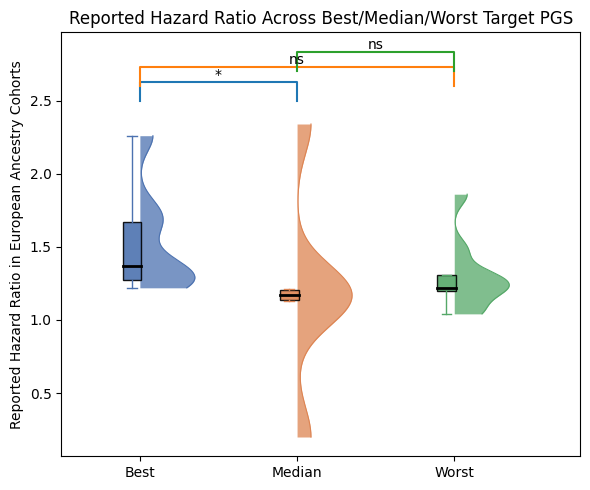

In [27]:
import matplotlib.pyplot as plt
from scipy.stats import kruskal, mannwhitneyu

num_variant_best = [x for x in days_best if pd.notna(x)]
num_variant_median = [x for x in days_median if pd.notna(x)]
num_variant_worst = [x for x in days_worst if pd.notna(x)]

# hypothesis testing
# overall test
stat, p_global = kruskal(
    num_variant_best,
    num_variant_median,
    num_variant_worst
)

print("Global p:", p_global)

# pairwise
p1 = mannwhitneyu(num_variant_best, num_variant_median).pvalue
p2 = mannwhitneyu(num_variant_best, num_variant_worst).pvalue
p3 = mannwhitneyu(num_variant_median, num_variant_worst).pvalue

colors = ['#4C72B0', '#DD8452', '#55A868']
labels = ["Best", "Median", "Worst"]
data = [num_variant_best, num_variant_median, num_variant_worst]
positions = [1, 2, 3]

fig, ax = plt.subplots(figsize=(6, 5))

for pos, d, color in zip(positions, data, colors):
    half_violin(ax, d, pos, color, width=0.35, log_scale=False)
    ax.boxplot(d, positions=[pos - 0.05], widths=0.12,
               showfliers=False, patch_artist=True,
               medianprops=dict(color='black', linewidth=2),
               boxprops=dict(facecolor=color, alpha=0.9),
               whiskerprops=dict(color=color),
               capprops=dict(color=color))

ax.set_xticks(positions)
ax.set_xticklabels(labels)
ax.set_xlim(0.5, 3.8)
ax.set_ylabel("Reported Hazard Ratio in European Ancestry Cohorts")
ax.set_title("Reported Hazard Ratio Across Best/Median/Worst Target PGS")

add_significance(ax, 1, 2, 2.5, p1)
add_significance(ax, 1, 3, 2.6, p2)
add_significance(ax, 2, 3, 2.7, p3)

plt.tight_layout()
plt.show()

### Fit model on Metadata

#### Generate Training Sample

In [9]:
import pandas as pd
import numpy as np
import ast
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.pipeline import Pipeline
import warnings
warnings.filterwarnings('ignore')

today = pd.Timestamp.today()
rows = []

for trait in target_rank_matrix.index:
    # select target PGS more than 10 PGS
    target_cols = target_rank_matrix.loc[trait].dropna().tolist()
    perf_series = original_matrix.loc[trait, target_cols].dropna()
    if len(perf_series) < 10:
        continue
    ranked = perf_series.rank(ascending=False)
    n_target = len(ranked)

    # construct feature map
    for col, abs_rank in ranked.items():
        pgs_id = col.split("__")[1]
        if pgs_id not in metainfo.index:
            continue
        meta = metainfo.loc[pgs_id]

        # training feature
        num_var   = pd.to_numeric(meta.get("num_variant", np.nan), errors='coerce')
        num_train = pd.to_numeric(meta.get("num_training_sample", np.nan), errors='coerce')
        num_eval  = pd.to_numeric(meta.get("num_eval", np.nan), errors='coerce')
        try:
            days_since = (today - pd.to_datetime(meta["date_release"])).days
        except:
            days_since = np.nan

        # training_ancestry
        ancestry    = str(meta.get("training_ancestry", "")).lower()
        is_european = int("european" in ancestry)

        # training_method
        method = str(meta.get("training_method", "")).lower()
        if "ldpred" in method:
            method_cat = "ldpred"
        elif any(k in method for k in ["penalized", "lasso", "ridge", "elastic", "bigstatsr"]):
            method_cat = "penalized"
        elif any(k in method for k in ["clump", "threshold", "c+t", "p+t", "prunin"]):
            method_cat = "ct"
        elif any(k in method for k in ["bayesian", "bayes", "sbayess", "prscsx"]):
            method_cat = "bayesian"
        else:
            method_cat = "other"
        is_ldpred    = int(method_cat == "ldpred")
        is_penalized = int(method_cat == "penalized")
        is_ct        = int(method_cat == "ct")
        is_bayesian  = int(method_cat == "bayesian")

        # eval features
        try:
            eval_est  = ast.literal_eval(meta["eval_estimate"])
            eval_anc  = ast.literal_eval(meta["eval_ancestry"])
            eval_met  = ast.literal_eval(meta["eval_metrics"])
            eval_samp = ast.literal_eval(meta["num_eval_sample"])

            # construct a pair for each evaluation in European
            eur_pairs = [
                (float(e), str(m_).lower(), s)
                for e, a, m_, s in zip(eval_est, eval_anc, eval_met, eval_samp)
                if a == 'European' and e is not None
            ]

            def mean_by_kw(pairs, keywords):
                vals = [e for e, m_, _ in pairs if any(k in m_ for k in keywords)]
                return float(np.mean(vals)) if vals else np.nan
            
            # extract the first pair + log 标准化 estimate
            if eur_pairs:
                auc_mean = mean_by_kw(eur_pairs, ["auc", "auroc", "area under"])
                or_mean  = mean_by_kw(eur_pairs, ["odds ratio"])
                hr_mean  = mean_by_kw(eur_pairs, ["hazard ratio"])
                
                reported_auc = auc_mean
                reported_or  = np.log(or_mean) if or_mean is not np.nan and not np.isnan(or_mean) else np.nan
                reported_hr  = np.log(hr_mean) if hr_mean is not np.nan and not np.isnan(hr_mean) else np.nan

                eur_samples = [s for _, _, s in eur_pairs if s is not None]
                mean_eur_sample = float(np.mean(eur_samples)) if eur_samples else np.nan
            else:
                reported_auc = reported_or = reported_hr = np.nan
                mean_eur_sample = np.nan

        except:
            reported_auc = reported_or = reported_hr = np.nan
            mean_eur_sample = np.nan

        pct_rank = 1 - (abs_rank - 1) / (n_target - 1)
        # top 50% are selected as 1
        is_top_50percent = int(abs_rank <= n_target / 2)
        # top 10% are selected as 1
        is_top_10percent = int(abs_rank <= max(1, round(n_target * 0.1)))
        # only the best is selected as 1
        is_best = int(abs_rank == 1)

        rows.append({
            "trait": trait, "pgs_id": pgs_id,
            "num_variant":         num_var,
            "days_since_release":  days_since,
            "num_training_sample": num_train,
            "num_eval":            num_eval,
            "mean_eur_sample":     mean_eur_sample,
            "is_european":         is_european,
            "is_ldpred":           is_ldpred,
            "is_penalized":        is_penalized,
            "is_ct":               is_ct,
            "is_bayesian":         is_bayesian,
            "reported_auc":        reported_auc,
            "reported_or":         reported_or,
            "reported_hr":         reported_hr,
            "pct_rank":            pct_rank,
            "is_top_50percent":    is_top_50percent,
            "is_top_10percent":    is_top_10percent,
            "is_best":             is_best
        })

df_glm = pd.DataFrame(rows)
for col in ["reported_auc", "reported_or", "reported_hr"]:
    if col in df_glm.columns:
        df_glm[f"{col}_missing"] = df_glm[col].isna().astype(int)
        df_glm[col] = df_glm[col].fillna(df_glm[col].median())

features = [
    "num_variant", "days_since_release", "num_training_sample",
    "num_eval", "mean_eur_sample",
    "is_european", "is_ldpred", "is_penalized", "is_ct", "is_bayesian",
    "reported_auc", "reported_or", "reported_hr", 
]

print(f"Total samples: {len(df_glm)}")
print(f"\nMissing rate per feature:")
print(df_glm[features].isna().mean().round(3).to_string())

Total samples: 2093

Missing rate per feature:
num_variant            0.000
days_since_release     0.000
num_training_sample    0.008
num_eval               0.000
mean_eur_sample        0.123
is_european            0.000
is_ldpred              0.000
is_penalized           0.000
is_ct                  0.000
is_bayesian            0.000
reported_auc           0.000
reported_or            0.000
reported_hr            0.000


In [11]:
df_glm.to_csv("pgs_glm_features.csv", index=False)
print(f"Saved {len(df_glm)} rows to pgs_glm_features.csv")

Saved 2093 rows to pgs_glm_features.csv


#### Binary Classification

Samples: 1832
Dropped: 261
Logistic             AUC: 0.6943 ± 0.0244
Random Forest        AUC: 0.7601 ± 0.0242
Gradient Boosting    AUC: 0.7767 ± 0.0131


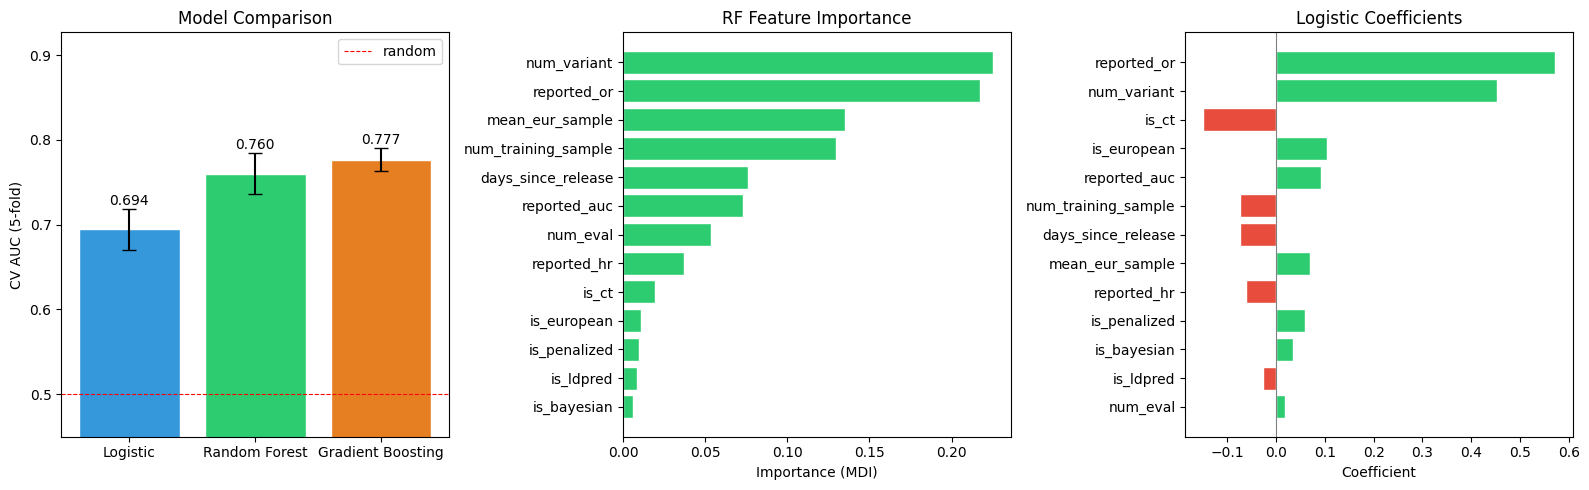


Logistic Coefficients (top 10):
            Feature  Coefficient  Odds Ratio
        reported_or     0.572533    1.772752
        num_variant     0.451902    1.571298
              is_ct    -0.150398    0.860365
        is_european     0.103401    1.108936
       reported_auc     0.092156    1.096536
num_training_sample    -0.074993    0.927750
 days_since_release    -0.073924    0.928742
    mean_eur_sample     0.068545    1.070949
        reported_hr    -0.062602    0.939317
       is_penalized     0.058157    1.059882


In [12]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt

df_data = df_glm[features + ["is_top_50percent", "pct_rank"]].copy()
df_clean = df_data[features + ["is_top_50percent"]].dropna()
print(f"Samples: {len(df_clean)}")
print(f"Dropped: {len(df_glm) - len(df_clean)}")

X = df_clean[features].values.astype(float)
y = df_clean["is_top_50percent"].values

# log transform 偏态列
log_cols = ["num_variant", "num_training_sample", "mean_eur_sample"]
log_idx  = [features.index(c) for c in log_cols]
X[:, log_idx] = np.log1p(X[:, log_idx])

cv = StratifiedKFold(5, shuffle=True, random_state=42)

# model comparison
model_dict = {
    "Logistic":          Pipeline([("scaler", StandardScaler()), ("clf", LogisticRegression(max_iter=1000))]),
    "Random Forest":     RandomForestClassifier(n_estimators=200, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=200, random_state=42),
}

results = {}
for name, model in model_dict.items():
    aucs = cross_val_score(model, X, y, cv=cv, scoring='roc_auc')
    results[name] = aucs
    print(f"{name:<20} AUC: {aucs.mean():.4f} ± {aucs.std():.4f}")

# RF feature importance
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X, y)
imp = pd.Series(rf.feature_importances_, index=features).sort_values(ascending=True)

# Logistic coefficients
lr_pipe = Pipeline([("scaler", StandardScaler()), ("clf", LogisticRegression(max_iter=1000))])
lr_pipe.fit(X, y)
coef_df = pd.DataFrame({
    "Feature":     features,
    "Coefficient": lr_pipe.named_steps["clf"].coef_[0],
    "Odds Ratio":  np.exp(lr_pipe.named_steps["clf"].coef_[0]),
}).sort_values("Coefficient", key=abs, ascending=False)

# ---- 可视化 ----
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 1. AUC 对比
names  = list(results.keys())
means  = [results[n].mean() for n in names]
stds   = [results[n].std()  for n in names]
colors = ['#3498db', '#2ecc71', '#e67e22']
axes[0].bar(names, means, yerr=stds, color=colors, capsize=5, edgecolor='white')
axes[0].axhline(0.5, color='red', linestyle='--', linewidth=0.8, label='random')
axes[0].set_ylim(0.45, min(1.0, max(means) + 0.15))
axes[0].set_ylabel("CV AUC (5-fold)")
axes[0].set_title("Model Comparison")
axes[0].legend()
for i, (m, s) in enumerate(zip(means, stds)):
    axes[0].text(i, m + s + 0.005, f"{m:.3f}", ha='center', fontsize=10)

# 2. RF feature importance (top 15)
imp_top = imp.tail(15)
axes[1].barh(imp_top.index, imp_top.values, color='#2ecc71', edgecolor='white')
axes[1].set_xlabel("Importance (MDI)")
axes[1].set_title("RF Feature Importance")

# 3. Logistic coefficients (top 15 by abs value)
coef_top = coef_df.head(15).iloc[::-1]
bar_colors = ['#2ecc71' if c > 0 else '#e74c3c' for c in coef_top["Coefficient"]]
axes[2].barh(coef_top["Feature"], coef_top["Coefficient"], color=bar_colors, edgecolor='white')
axes[2].axvline(0, color='gray', linewidth=0.8)
axes[2].set_xlabel("Coefficient")
axes[2].set_title("Logistic Coefficients")

plt.tight_layout()
plt.show()

print("\nLogistic Coefficients (top 10):")
print(coef_df.head(10).to_string(index=False))

In [13]:
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import cross_val_predict
cv = StratifiedKFold(5, shuffle=True, random_state=42)

print(f"{'Model':<20} {'AUC':>8} {'Accuracy':>10} {'F1':>8}")
print("-" * 50)

for name, model in model_dict.items():
    auc  = cross_val_score(model, X, y, cv=cv, scoring='roc_auc').mean()
    acc  = cross_val_score(model, X, y, cv=cv, scoring='accuracy').mean()
    f1   = cross_val_score(model, X, y, cv=cv, scoring='f1').mean()
    print(f"{name:<20} {auc:>8.4f} {acc:>10.4f} {f1:>8.4f}")

# 详细报告（用 Gradient Boosting 为例）
gb = GradientBoostingClassifier(n_estimators=200, random_state=42)
y_pred = cross_val_predict(gb, X, y, cv=cv)
print(f"\nGradient Boosting Classification Report:")
print(classification_report(y, y_pred, target_names=["Bottom 50%", "Top 50%"]))


Model                     AUC   Accuracy       F1
--------------------------------------------------
Logistic               0.6943     0.6540   0.6635
Random Forest          0.7601     0.6900   0.6882
Gradient Boosting      0.7767     0.7009   0.7100

Gradient Boosting Classification Report:
              precision    recall  f1-score   support

  Bottom 50%       0.70      0.68      0.69       901
     Top 50%       0.70      0.72      0.71       931

    accuracy                           0.70      1832
   macro avg       0.70      0.70      0.70      1832
weighted avg       0.70      0.70      0.70      1832



In [14]:
from sklearn.model_selection import KFold

df_cv = df_glm[features + ["is_best", "trait"]].dropna().copy()
X_all = df_cv[features].values.astype(float)
X_all[:, log_idx] = np.log1p(X_all[:, log_idx])
y_all = df_cv["is_best"].values
traits_all = df_cv["trait"].values

# trait-level 5-fold split
unique_traits = np.array(sorted(df_cv["trait"].unique()))
kf = KFold(n_splits=5, shuffle=True, random_state=42)

all_overlap_rows = []

for fold, (train_trait_idx, test_trait_idx) in enumerate(kf.split(unique_traits)):
    train_traits = set(unique_traits[train_trait_idx])
    test_traits  = set(unique_traits[test_trait_idx])

    train_mask = df_cv["trait"].isin(train_traits).values
    test_mask  = df_cv["trait"].isin(test_traits).values

    X_train, y_train = X_all[train_mask], y_all[train_mask]
    X_test           = X_all[test_mask]

    gb_fold = GradientBoostingClassifier(n_estimators=200, random_state=42)
    gb_fold.fit(X_train, y_train)
    y_prob_test = gb_fold.predict_proba(X_test)[:, 1]

    df_test = df_cv[test_mask][["trait", "is_best"]].copy()
    df_test["y_prob"] = y_prob_test

    for trait, g in df_test.groupby("trait"):
        n_total = len(g)
        k = max(1, round(n_total * 0.1))
        k = max(1, round(n_total * 0.5))
        k = 1
        true_top = set(g[g["is_best"] == 1].index)
        pred_top = set(g["y_prob"].nlargest(k).index)
        overlap  = len(true_top & pred_top)
        n_true   = len(true_top)

        all_overlap_rows.append({
            "fold":         fold + 1,
            "trait":        trait,
            "n_total":      n_total,
            "n_true_top10": n_true,
            "overlap":      overlap,
            "recall":       overlap / n_true if n_true > 0 else np.nan,
            "precision":    overlap / k      if k > 0     else np.nan,
        })

    print(f"Fold {fold+1}: test traits={len(test_traits)}, "
          f"recall={np.nanmean([r['recall'] for r in all_overlap_rows if r['fold']==fold+1]):.4f}")

overlap_df = pd.DataFrame(all_overlap_rows)
print(f"\nOverall Recall@Best  : {overlap_df['recall'].mean():.4f} ± {overlap_df['recall'].std():.4f}")
print(f"Overall Precision@Best : {overlap_df['precision'].mean():.4f} ± {overlap_df['precision'].std():.4f}")
print(f"\nRecall = 1.0 : {(overlap_df['recall'] == 1.0).sum()} traits")
print(f"Recall = 0.0 : {(overlap_df['recall'] == 0.0).sum()} traits")
print(overlap_df[["fold", "trait", "n_total", "n_true_top10", "overlap", "recall", "precision"]].to_string(index=False))


Fold 1: test traits=9, recall=0.0000
Fold 2: test traits=8, recall=0.1429
Fold 3: test traits=8, recall=0.1429
Fold 4: test traits=8, recall=0.2500
Fold 5: test traits=8, recall=0.0000

Overall Recall@Best  : 0.1111 ± 0.3187
Overall Precision@Best : 0.0976 ± 0.3004

Recall = 1.0 : 4 traits
Recall = 0.0 : 32 traits
 fold trait  n_total  n_true_top10  overlap  recall  precision
    1   C54       14             1        0     0.0        0.0
    1   C64       10             1        0     0.0        0.0
    1   C91       13             1        0     0.0        0.0
    1   G30       37             1        0     0.0        0.0
    1   I24       33             1        0     0.0        0.0
    1   I25      219             1        0     0.0        0.0
    1   J44       10             1        0     0.0        0.0
    1   N18       21             1        0     0.0        0.0
    1   N41       82             1        0     0.0        0.0
    2   C61       79             1        0     0.0   

In [36]:
print(f"\nOverall Recall@Best : {overlap_df['recall'].mean():.4f} ± {overlap_df['recall'].std():.4f}")
print(f"Overall Precision@Best: {overlap_df['precision'].mean():.4f} ± {overlap_df['precision'].std():.4f}")
print(f"Mean overlap count    : {overlap_df['overlap'].mean():.2f} / {overlap_df['n_true_top10'].mean():.2f}")


Overall Recall@Best : 0.1944 ± 0.4014
Overall Precision@Best: 0.1707 ± 0.3809
Mean overlap count    : 0.17 / 0.88


#### Continuous Regression

Samples: 1832

Model                      R²      MAE
----------------------------------------
Linear (Ridge)         0.1098   0.2318
Random Forest          0.3060   0.1887
Gradient Boosting      0.3194   0.1915


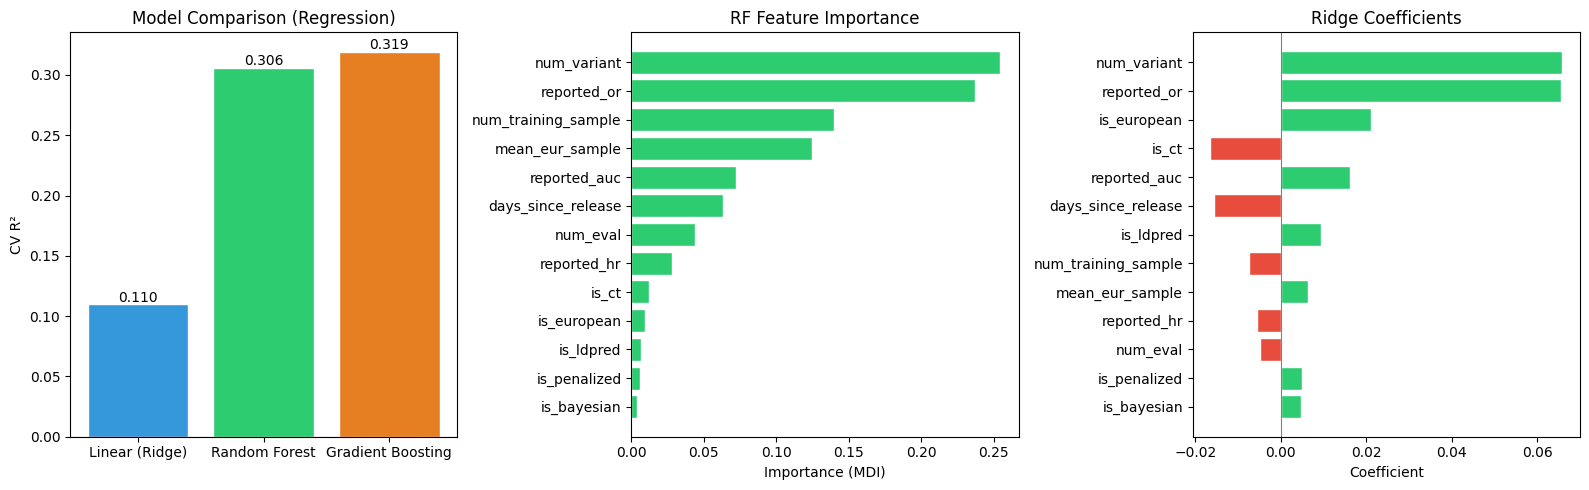

In [15]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.model_selection import cross_val_score, cross_val_predict, KFold
from sklearn.metrics import r2_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

df_clean = df_glm[features + ["pct_rank"]].dropna()
print(f"Samples: {len(df_clean)}")

X = df_clean[features].values.astype(float)
y = df_clean["pct_rank"].values

log_cols = ["num_variant", "num_training_sample", "num_eval", "n_eur_eval", "mean_eur_sample"]
log_idx  = [features.index(c) for c in log_cols if c in features]
X[:, log_idx] = np.log1p(X[:, log_idx])

cv = KFold(5, shuffle=True, random_state=42)

model_dict = {
    "Linear (Ridge)":    Pipeline([("scaler", StandardScaler()), ("reg", Ridge())]),
    "Random Forest":     RandomForestRegressor(n_estimators=200, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=200, random_state=42),
}

print(f"\n{'Model':<20} {'R²':>8} {'MAE':>8}")
print("-" * 40)
results = {}
for name, model in model_dict.items():
    r2  = cross_val_score(model, X, y, cv=cv, scoring='r2').mean()
    mae = -cross_val_score(model, X, y, cv=cv, scoring='neg_mean_absolute_error').mean()
    results[name] = r2
    print(f"{name:<20} {r2:>8.4f} {mae:>8.4f}")

# RF feature importance
rf = RandomForestRegressor(n_estimators=200, random_state=42)
rf.fit(X, y)
imp = pd.Series(rf.feature_importances_, index=features).sort_values(ascending=True)

# Ridge coefficients
ridge_pipe = Pipeline([("scaler", StandardScaler()), ("reg", Ridge())])
ridge_pipe.fit(X, y)
coef_df = pd.DataFrame({
    "Feature":     features,
    "Coefficient": ridge_pipe.named_steps["reg"].coef_,
}).sort_values("Coefficient", key=abs, ascending=False)

# ---- 可视化 ----
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# R² 对比
names = list(results.keys())
vals  = list(results.values())
colors = ['#3498db', '#2ecc71', '#e67e22']
axes[0].bar(names, vals, color=colors, edgecolor='white')
axes[0].axhline(0, color='red', linestyle='--', linewidth=0.8)
axes[0].set_ylabel("CV R²")
axes[0].set_title("Model Comparison (Regression)")
for i, v in enumerate(vals):
    axes[0].text(i, v + 0.002, f"{v:.3f}", ha='center', fontsize=10)

# RF feature importance
axes[1].barh(imp.tail(15).index, imp.tail(15).values, color='#2ecc71', edgecolor='white')
axes[1].set_xlabel("Importance (MDI)")
axes[1].set_title("RF Feature Importance")

# Ridge coefficients
coef_top = coef_df.head(15).iloc[::-1]
bar_colors = ['#2ecc71' if c > 0 else '#e74c3c' for c in coef_top["Coefficient"]]
axes[2].barh(coef_top["Feature"], coef_top["Coefficient"], color=bar_colors, edgecolor='white')
axes[2].axvline(0, color='gray', linewidth=0.8)
axes[2].set_xlabel("Coefficient")
axes[2].set_title("Ridge Coefficients")

plt.tight_layout()
plt.show()


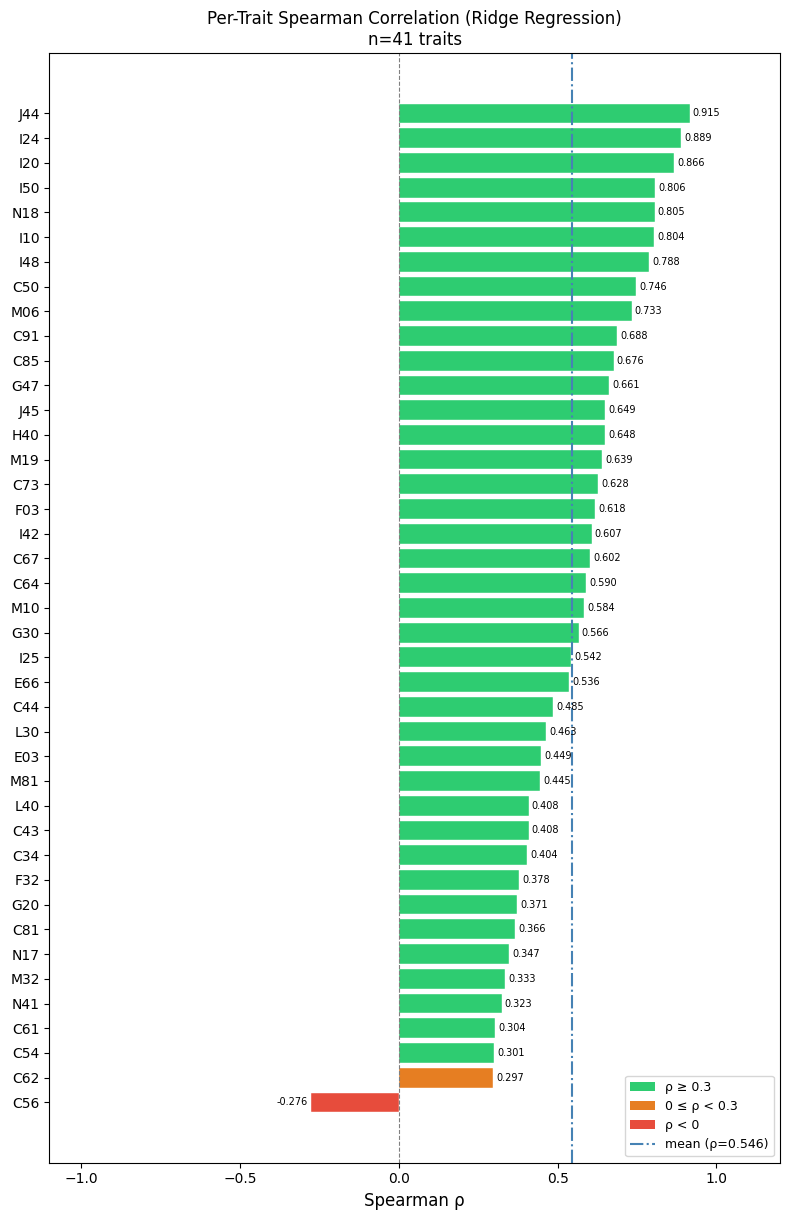

ρ ≥ 0.3 : 39 traits
0 ≤ ρ < 0.3: 1 traits
ρ < 0   : 1 traits


In [16]:
from sklearn.model_selection import cross_val_predict, KFold
from scipy.stats import spearmanr

df_clean = df_glm[features + ["pct_rank", "trait"]].dropna()
X = df_clean[features].values.astype(float)
X[:, log_idx] = np.log1p(X[:, log_idx])
y_cont = df_clean["pct_rank"].values

gb_reg = GradientBoostingRegressor(n_estimators=200, random_state=42)
# rf_reg = RandomForestRegressor(n_estimators=200, random_state=42)
# ridge_reg = Pipeline([("scaler", StandardScaler()), ("reg", Ridge())])
y_pred_cv = cross_val_predict(gb_reg, X, y_cont, cv=KFold(5, shuffle=True, random_state=42))

df_clean = df_clean.copy()
df_clean["y_pred"] = y_pred_cv  # 换成 CV 预测
df_clean["y_cont"] = y_cont

def per_trait_metrics(g):
    if len(g) < 5:
        return pd.Series({"r2": np.nan, "spearman": np.nan})
    r2  = r2_score(g["y_cont"], g["y_pred"])
    rho = spearmanr(g["y_cont"], g["y_pred"]).statistic
    return pd.Series({"r2": r2, "spearman": rho})

per_trait = df_clean.groupby("trait").apply(per_trait_metrics).dropna()
per_trait_sorted = per_trait.sort_values("spearman")

fig, ax = plt.subplots(figsize=(8, max(5, len(per_trait_sorted) * 0.3)))

colors = ['#2ecc71' if v >= 0.3 else '#e67e22' if v >= 0 else '#e74c3c'
          for v in per_trait_sorted["spearman"]]
bars = ax.barh(per_trait_sorted.index, per_trait_sorted["spearman"],
               color=colors, edgecolor='white', linewidth=0.3)

ax.axvline(0, color='gray', linewidth=0.8, linestyle='--')
ax.axvline(per_trait_sorted["spearman"].mean(), color='steelblue',
           linewidth=1.5, linestyle='-.', label=f'mean (ρ={per_trait_sorted["spearman"].mean():.3f})')

for i, (trait, row) in enumerate(per_trait_sorted.iterrows()):
    v = row["spearman"]
    ax.text(v + 0.01 if v >= 0 else v - 0.01, i,
            f"{v:.3f}", va='center', ha='left' if v >= 0 else 'right', fontsize=7)

ax.set_xlabel("Spearman ρ", fontsize=12)
ax.set_title(f"Per-Trait Spearman Correlation (Ridge Regression)\n"
             f"n={len(per_trait_sorted)} traits", fontsize=12)
ax.set_xlim(-1.1, 1.2)
ax.legend(fontsize=9)

# 颜色图例
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#2ecc71', label='ρ ≥ 0.3'),
                   Patch(facecolor='#e67e22', label='0 ≤ ρ < 0.3'),
                   Patch(facecolor='#e74c3c', label='ρ < 0')]
ax.legend(handles=legend_elements + [plt.Line2D([0], [0], color='steelblue', linestyle='-.',
          label=f'mean (ρ={per_trait_sorted["spearman"].mean():.3f})')],
          fontsize=9, loc='lower right')

plt.tight_layout()
plt.show()

print(f"ρ ≥ 0.3 : {(per_trait_sorted['spearman'] >= 0.3).sum()} traits")
print(f"0 ≤ ρ < 0.3: {((per_trait_sorted['spearman'] >= 0) & (per_trait_sorted['spearman'] < 0.3)).sum()} traits")
print(f"ρ < 0   : {(per_trait_sorted['spearman'] < 0).sum()} traits")

In [34]:
print(y_pred_cv)

[0.49930822 0.57295446 0.50926032 ... 0.39022131 0.35298768 0.39022131]


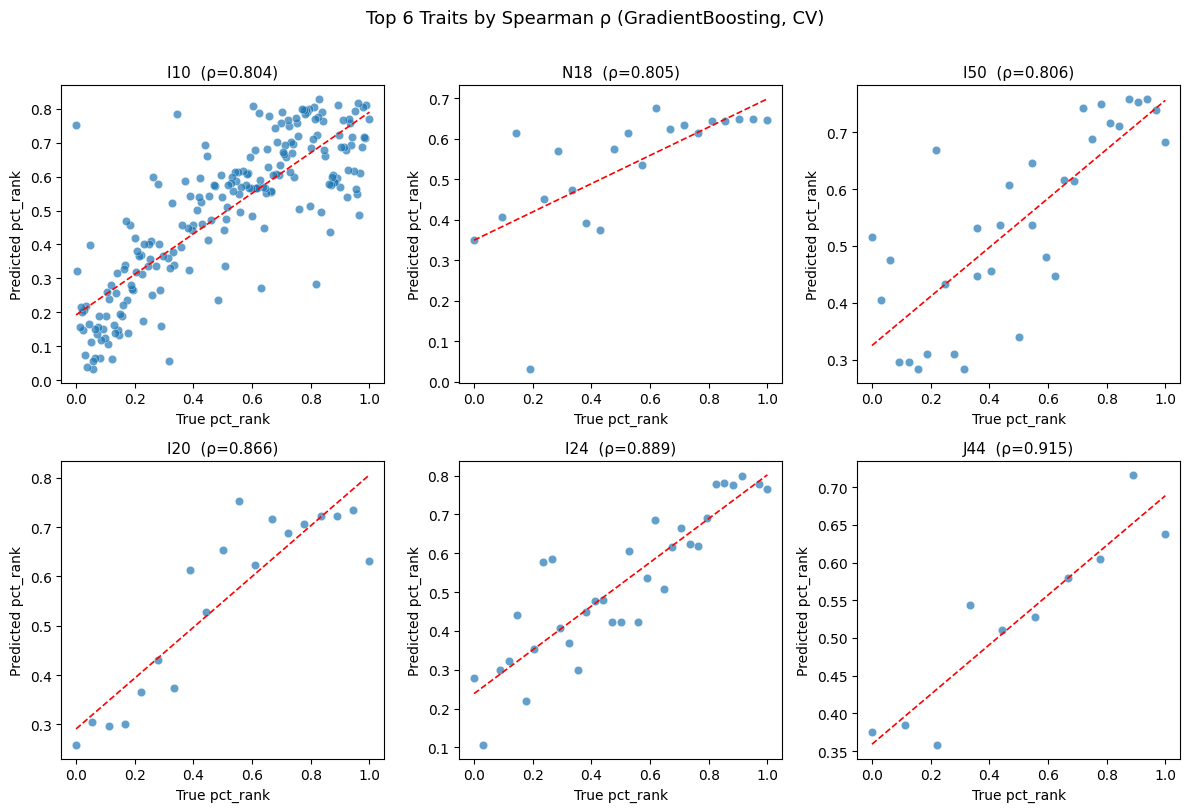

In [17]:
# 取 spearman 最高的 top 6 traits
top_traits = per_trait_sorted.tail(6).index.tolist()

fig, axes = plt.subplots(2, 3, figsize=(12, 8))
axes = axes.flatten()

for i, trait in enumerate(top_traits):
    g = df_clean[df_clean["trait"] == trait]
    rho = per_trait_sorted.loc[trait, "spearman"]

    axes[i].scatter(g["y_cont"], g["y_pred"], alpha=0.7, edgecolors='white', linewidth=0.3)

    # 趋势线
    z = np.polyfit(g["y_cont"], g["y_pred"], 1)
    x_line = np.linspace(g["y_cont"].min(), g["y_cont"].max(), 100)
    axes[i].plot(x_line, np.poly1d(z)(x_line), color='red', linewidth=1.2, linestyle='--')

    axes[i].set_xlabel("True pct_rank", fontsize=10)
    axes[i].set_ylabel("Predicted pct_rank", fontsize=10)
    axes[i].set_title(f"{trait}  (ρ={rho:.3f})", fontsize=11)

plt.suptitle("Top 6 Traits by Spearman ρ (GradientBoosting, CV)", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()